# SDI and GSI Pipeline

This notebook contains the pipeline to build an evaluation score metrics for a primary school's "goodness"


## Project objective
Build a school-year panel that:
1. extracts Primary 1 2B and 2C demand-pressure data,
2. computes a **School Demand Index (SDI)**,
3. merges SDI with institutional indicators such as **GEP** and **SAP**,
4. computes a **Good School Index (GSI)**, and
5. flags schools above year-specific percentile thresholds.


In [1]:

from __future__ import annotations

import logging
import math
import re
from pathlib import Path
from typing import Iterable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from bs4 import BeautifulSoup
from scipy.stats import zscore

# -----------------------------------------------------------------------------
# Project paths and runtime settings
# -----------------------------------------------------------------------------
PROJECT_ROOT = Path.cwd().parent
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "Good_School_index"

BALLLOTING_CACHE = OUTPUT_DIR / "school_year_2B_2C_panel.csv"
GEP_SAP_CACHE = OUTPUT_DIR / "property2b2c_school_year_gep_sap.csv"
FINAL_OUTPUT = PROJECT_ROOT/ "outputs" / "Good_School_index.csv"

YEARS = range(2009, 2026)
BASE_URL = "https://sgschooling.com/year/{year}/all"
HEADERS = {"User-Agent": "Mozilla/5.0"}

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")

In [19]:
BALLLOTING_CACHE

PosixPath('/Users/larryyyyy/Documents/DSA4264/Github project/DSA4264-Public-Policy-and-Society/outputs/Good_School_index/school_year_2B_2C_panel.csv')

## 1. Helper functions

These helpers keep the parsing logic readable and testable.

In [12]:

def clean_text(text: str) -> str:
    """Collapse repeated whitespace and return a cleaned string."""
    return " ".join(str(text).split())


def parse_regular_cell(text: str) -> int:
    """Parse simple count cells such as '53' or '-' into integers."""
    s = clean_text(text)
    if not s or s == "-":
        return 0

    match = re.search(r"\b\d+\b", s)
    return int(match.group()) if match else 0


def parse_taken_cell(text: str) -> int:
    """Parse 'Taken' cells, which often contain richer text patterns."""
    s = clean_text(text)
    if not s or s == "-":
        return 0

    # Example: '65 SC1-2 17/12' -> 65
    match = re.search(r"(?<!/)\b\d+\b(?!/)", s)
    if match:
        return int(match.group())

    # Fallback if only ratio-like content is found
    ratio = re.search(r"(\d+)\s*/\s*(\d+)", s)
    if ratio:
        return int(ratio.group(2))

    return 0


def detect_phase_layout(header_cells: list[str]) -> list[str]:
    """Identify whether the year uses the split 2A(1)/2A(2) layout."""
    cells = [clean_text(x) for x in header_cells]
    if "2A(1)" in cells and "2A(2)" in cells:
        return ["Phase 1", "2A(1)", "2A(2)", "2B", "2C", "2C(S)", "3"]
    return ["Phase 1", "2A", "2B", "2C", "2C(S)", "3"]


def extract_header_phases(soup: BeautifulSoup) -> list[str]:
    """Read the table header and recover the phase layout."""
    for row in soup.select("tr"):
        cells = row.find_all(["th", "td"])
        texts = [clean_text(c.get_text(" ", strip=True)) for c in cells]
        if texts and texts[0] == "School":
            return detect_phase_layout(texts[1:])
    raise ValueError("Could not find a valid header row.")


def is_school_row(first_cell: str) -> bool:
    """Return True when a row starts a new school block."""
    s = clean_text(first_cell)
    invalid_prefixes = {"School", "P1 Ballot History", "All Primary Schools"}
    if not s or s.startswith("↳") or s in invalid_prefixes:
        return False
    if "Vacancy" in s or "Applied" in s or "Taken" in s:
        return False
    return True


def extract_phase_values(texts: list[str], phases: list[str], row_type: str) -> dict[str, int]:
    """Map a table row into a {phase: value} dictionary."""
    parser = parse_taken_cell if row_type == "taken" else parse_regular_cell
    raw_cells = texts[1 : 1 + len(phases)]
    values = {phase: parser(cell) for phase, cell in zip(phases, raw_cells)}
    for phase in phases:
        values.setdefault(phase, 0)
    return values

## 2. Scrape the 2B and 2C school-year panel


In [13]:

def parse_year(year: int, timeout: int = 40) -> list[dict]:
    """Scrape one year of school-level phase data from sgschooling."""
    url = BASE_URL.format(year=year)
    response = requests.get(url, headers=HEADERS, timeout=timeout)
    response.raise_for_status()

    soup = BeautifulSoup(response.text, "html.parser")
    phases = extract_header_phases(soup)

    out: list[dict] = []
    current_school = None
    vacancy_vals = None
    applied_vals = None
    taken_vals = None

    for row in soup.select("tr"):
        cells = row.find_all(["th", "td"])
        if not cells:
            continue

        texts = [clean_text(c.get_text(" ", strip=True)) for c in cells]
        if not texts:
            continue

        first = texts[0]

        if is_school_row(first):
            current_school = first
            vacancy_vals = None
            applied_vals = None
            taken_vals = None
            continue

        if not current_school:
            continue

        if "Vacancy" in first:
            vacancy_vals = extract_phase_values(texts, phases, row_type="vacancy")
            continue

        if "Applied" in first:
            applied_vals = extract_phase_values(texts, phases, row_type="applied")
            continue

        if "Taken" in first:
            taken_vals = extract_phase_values(texts, phases, row_type="taken")

            if vacancy_vals is None:
                vacancy_vals = {p: 0 for p in phases}
            if applied_vals is None:
                applied_vals = {p: 0 for p in phases}
            if taken_vals is None:
                taken_vals = {p: 0 for p in phases}

            app_2b = applied_vals.get("2B", 0)
            app_2c = applied_vals.get("2C", 0)
            vac_2b = vacancy_vals.get("2B", 0)
            vac_2c = vacancy_vals.get("2C", 0)

            out.append(
                {
                    "school": current_school,
                    "year": year,
                    "applicants_2B": app_2b,
                    "applicants_2C": app_2c,
                    "vacancies_2B": vac_2b,
                    "vacancies_2C": vac_2c,
                    "taken_2B": taken_vals.get("2B", 0),
                    "taken_2C": taken_vals.get("2C", 0),
                    "balloted_year": int((app_2b > vac_2b) or (app_2c > vac_2c)),
                }
            )

            vacancy_vals = None
            applied_vals = None
            taken_vals = None

    return out


def build_balloting_panel(years: Iterable[int], save_cache: bool = True) -> pd.DataFrame:
    """Build the school-year panel across all requested years."""
    all_rows: list[dict] = []

    for year in years:
        rows = parse_year(year)
        logging.info("Parsed %s: %s schools", year, len(rows))
        all_rows.extend(rows)

    panel = (
        pd.DataFrame(all_rows)
        .groupby(["school", "year"], as_index=False)
        .first()
        .sort_values(["year", "school"])
        .reset_index(drop=True)
    )

    if save_cache:
        panel.to_csv(BALLLOTING_CACHE, index=False)
        

    return panel

In [14]:

# Run this only when you want to re-scrape from the website.
# If you already have the cached CSV, skip this cell.

#df_panel = build_balloting_panel(YEARS, save_cache=True)
#df_panel.head()

INFO: Parsed 2009: 168 schools
INFO: Parsed 2010: 169 schools
INFO: Parsed 2011: 170 schools
INFO: Parsed 2012: 177 schools
INFO: Parsed 2013: 180 schools
INFO: Parsed 2014: 180 schools
INFO: Parsed 2015: 183 schools
INFO: Parsed 2016: 183 schools
INFO: Parsed 2017: 184 schools
INFO: Parsed 2018: 184 schools
INFO: Parsed 2019: 185 schools
INFO: Parsed 2020: 186 schools
INFO: Parsed 2021: 181 schools
INFO: Parsed 2022: 181 schools
INFO: Parsed 2023: 181 schools
INFO: Parsed 2024: 180 schools
INFO: Parsed 2025: 179 schools


,school,year,applicants_2B,applicants_2C,vacancies_2B,vacancies_2C,taken_2B,taken_2C,balloted_year
0,Admiralty,2009,51,139,63,75,51,75,1
1,Ahmad Ibrahim,2009,3,71,59,116,3,70,0
2,Ai Tong,2009,65,64,45,48,45,48,1
3,Anchor Green,2009,0,110,95,189,0,110,0
4,Anderson,2009,25,116,57,88,25,88,1


In [15]:

# Preferred loading path for reproducibility
if BALLLOTING_CACHE.exists():
    df_panel = pd.read_csv(BALLLOTING_CACHE)
else:
    raise FileNotFoundError(
        f"Missing cached panel: {BALLLOTING_CACHE}. "
        "Either place the file there or uncomment the scraping cell above."
    )

df_panel.head()

,school,year,applicants_2B,applicants_2C,vacancies_2B,vacancies_2C,taken_2B,taken_2C,balloted_year
0,Admiralty,2009,51,139,63,75,51,75,1
1,Ahmad Ibrahim,2009,3,71,59,116,3,70,0
2,Ai Tong,2009,65,64,45,48,45,48,1
3,Anchor Green,2009,0,110,95,189,0,110,0
4,Anderson,2009,25,116,57,88,25,88,1


## 3. Validate the raw panel

This section helps stakeholders trust the pipeline before index construction.

In [20]:

def validate_balloting_panel(df: pd.DataFrame) -> pd.DataFrame:
    """Return a compact quality-check table for the raw panel."""
    checks = {
        "rows": len(df),
        "schools": df["school"].nunique(),
        "years": df["year"].nunique(),
        "duplicate_school_year_pairs": int(df.duplicated(["school", "year"]).sum()),
        "missing_school_names": int(df["school"].isna().sum()),
        "missing_years": int(df["year"].isna().sum()),
        "negative_counts_anywhere": int(
            (df.select_dtypes(include=[np.number]) < 0).any(axis=1).sum()
        ),
    }
    return pd.DataFrame({"metric": checks.keys(), "value": checks.values()})


validate_balloting_panel(df_panel)

,metric,value
0,rows,3051
1,schools,186
2,years,17
3,duplicate_school_year_pairs,0
4,missing_school_names,0
5,missing_years,0
6,negative_counts_anywhere,0


## 4. Compute the School Demand Index (SDI)

The SDI combines:
- a rolling ballot frequency component, and
- a ballot intensity component based on 2B and 2C pressure.

This version uses safe copying and clearer intermediate columns.

In [48]:

def safe_zscore(series: pd.Series) -> pd.Series:
    """Standardize a numeric series while preserving the original index."""
    values = zscore(series.astype(float), nan_policy="omit")
    return pd.Series(values, index=series.index)


def compute_sdi(
    df: pd.DataFrame,
    start_year: int = 2013,
    rolling_window: int = 5,
    intensity_weight: float = 0.7,
    across_phase_weight: float = 0.3,
) -> pd.DataFrame:
    """Construct SDI from rolling ballot frequency and ballot intensity."""
    out = df.sort_values(["school", "year"]).copy()

    out["RBF_st"] = (
        out.groupby("school")["balloted_year"]
        .transform(lambda s: s.rolling(window=rolling_window, min_periods=1).mean())
    )

    denom = out["vacancies_2B"] + out["vacancies_2C"]
    numer = out["applicants_2B"] + out["applicants_2C"]

    # Avoid divide-by-zero and log(0)
    ratio = np.where((denom > 0) & (numer > 0), numer / denom, np.nan)
    out["BI"] = np.log(ratio)

    out["across_phase_ballot"] = (
        (out["applicants_2B"] > out["vacancies_2B"])
        & (out["applicants_2C"] > out["vacancies_2C"])
    ).astype(int)

    out = out.loc[out["year"] >= start_year].copy()

    out["z_BI"] = intensity_weight * safe_zscore(out["BI"]) + across_phase_weight * out["across_phase_ballot"]
    out["z_RBF"] = safe_zscore(out["RBF_st"])
    out["SDI"] = (out["z_BI"] + out["z_RBF"]) / 2

    return out


df_sdi = compute_sdi(df_panel)
df_sdi[["school", "year", "RBF_st", "BI", "z_BI", "z_RBF", "SDI"]].head()

,school,year,RBF_st,BI,z_BI,z_RBF,SDI
684,Admiralty,2013,1.0,-0.091291,0.337804,1.110344,0.724074
864,Admiralty,2014,1.0,-0.054067,0.367339,1.110344,0.738841
1044,Admiralty,2015,1.0,-0.160682,0.282748,1.110344,0.696546
1227,Admiralty,2016,1.0,-0.195567,0.255070,1.110344,0.682707
1410,Admiralty,2017,1.0,-0.068993,0.355497,1.110344,0.732920


## 5. Load and merge GEP/SAP data

Best practice is to **cache** this dataset as a CSV after scraping once.
That makes the notebook more reproducible and less dependent on fragile browser automation.

In [58]:

def clean_school_names(df: pd.DataFrame, school_col: str = "school") -> pd.DataFrame:
    """Standardize school names before merging."""
    out = df.copy()
    out[school_col] = out[school_col].str.replace("’", "'", regex=False)
    out[school_col] = out[school_col].str.replace("Anglo-Chinese (Primary)", "Anglo-Chinese", regex=False)
    return out


if GEP_SAP_CACHE.exists():
    gep_sap = pd.read_csv(GEP_SAP_CACHE)
else:
    raise FileNotFoundError(
        f"Missing GEP/SAP cache: {GEP_SAP_CACHE}. "
        "Place the CSV in the data folder before running this section."
    )

df_sdi = clean_school_names(df_sdi, "school")
gep_sap = clean_school_names(gep_sap, "school")

full_df = df_sdi[["school", "year", "SDI"]].merge(
    gep_sap,
    how="left",
    on=["school", "year"],
    validate="one_to_one",
)


# The rows with NA are primary schools that do not exists
full_df= full_df.dropna()
full_df

,school,year,SDI,GEP,SAP
0,Admiralty,2013,0.724074,0.0,0.0
1,Admiralty,2014,0.738841,0.0,0.0
2,Admiralty,2015,0.696546,0.0,0.0
3,Admiralty,2016,0.682707,0.0,0.0
4,Admiralty,2017,0.732920,0.0,0.0
...,...,...,...,...,...
2362,Zhonghua,2021,-1.351795,0.0,0.0
2363,Zhonghua,2022,-1.516608,0.0,0.0
2364,Zhonghua,2023,-1.313801,0.0,0.0
2365,Zhonghua,2024,-1.093843,0.0,0.0


## 6. Compute the Good School Index (GSI) and percentile flags

In [ ]:
# Replace the weights here for robust weights
# Robust 1: sdi_weight = 0.7, gep_weight = 0.15, sap_weight = 0.15
# Robust 2: sdi_weight = 0.8, gep_weight = 0.1, sap_weight = 0.1
def compute_gsi(
    df: pd.DataFrame,
    sdi_weight: float = 0.6,
    gep_weight: float = 0.2,
    sap_weight: float = 0.2,
) -> pd.DataFrame:
    """Construct GSI from standardized SDI plus GEP and SAP indicators."""
    out = df.dropna(subset=["SDI"]).copy()
    out["GSI"] = (
        sdi_weight * safe_zscore(out["SDI"])
        + gep_weight * out["GEP"]
        + sap_weight * out["SAP"]
    )
    return out


def add_year_specific_threshold_flags(
    df: pd.DataFrame,
    thresholds: list[float] = [0.75, 0.80, 0.85, 0.90],
) -> pd.DataFrame:
    """Add year-specific percentile thresholds and binary good-school flags."""
    out = df.copy()
    for q in thresholds:
        pct = int(q * 100)
        cutoff_col = f"GSI_p{pct}_year"
        flag_col = f"good_school_{pct}"

        out[cutoff_col] = out.groupby("year")["GSI"].transform(lambda x: x.quantile(q))
        out[flag_col] = (out["GSI"] >= out[cutoff_col]).astype(int)

    return out


full_df = compute_gsi(full_df)
full_df = add_year_specific_threshold_flags(full_df)
full_df.head()

,school,year,SDI,GEP,SAP,GSI,GSI_p75_year,good_school_75,GSI_p80_year,good_school_80,GSI_p85_year,good_school_85,GSI_p90_year,good_school_90
0,Admiralty,2013,0.724074,0.0,0.0,0.491796,0.538522,0,0.605995,0,0.707201,0,0.883978,0
1,Admiralty,2014,0.738841,0.0,0.0,0.502385,0.532038,0,0.678487,0,0.752863,0,0.847308,0
2,Admiralty,2015,0.696546,0.0,0.0,0.472056,0.502992,0,0.547279,0,0.681071,0,0.746760,0
3,Admiralty,2016,0.682707,0.0,0.0,0.462133,0.476894,0,0.508164,0,0.658572,0,0.699376,0
4,Admiralty,2017,0.732920,0.0,0.0,0.498139,0.496496,1,0.538539,0,0.668223,0,0.732952,0


In [60]:
original = pd.read_csv("../outputs/Good_School_index.csv", index_col=0)

## 7. Stakeholder-facing artifacts

These charts make the notebook easier to understand for supervisors, policy readers, and future collaborators.

In [74]:

def plot_balloted_share_over_time(df: pd.DataFrame) -> None:
    yearly = (
        df.groupby("year", as_index=False)["balloted_year"]
        .mean()
        .rename(columns={"balloted_year": "share_balloted"})
    )

    plt.figure(figsize=(9, 5))
    plt.plot(yearly["year"], yearly["share_balloted"], marker="o")
    plt.title("Share of Schools with 2B or 2C Balloting by Year")
    plt.xlabel("Year")
    plt.ylabel("Share")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_sdi_distribution(df: pd.DataFrame, selected_year: int) -> None:
    subset = df.loc[df["year"] == selected_year, "SDI"].dropna()

    plt.figure(figsize=(8, 5))
    plt.hist(subset, bins=20)
    plt.title(f"SDI Distribution in {selected_year}")
    plt.xlabel("SDI")
    plt.ylabel("Number of Schools")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_top_gsi_schools(df: pd.DataFrame, selected_year: int, top_n: int = 15) -> None:
    subset = (
        df.loc[df["year"] == selected_year, ["school", "GSI"]]
        .sort_values("GSI", ascending=False)
        .head(top_n)
        .sort_values("GSI")
    )

    plt.figure(figsize=(9, 6))
    plt.barh(subset["school"], subset["GSI"])
    plt.title(f"Top {top_n} Schools by GSI in {selected_year}")
    plt.xlabel("GSI")
    plt.ylabel("School")
    plt.tight_layout()
    plt.show()


def plot_good_school_persistence(df: pd.DataFrame, flag_col: str = "good_school_80") -> None:
    top_by_year = df[df[flag_col] == 1].groupby("year")["school"].apply(set)

    years = sorted(top_by_year.index)
    retention_rates = []
    transition_years = []

    for i in range(1, len(years)):
        prev = top_by_year[years[i - 1]]
        curr = top_by_year[years[i]]
        retention = len(prev & curr) / len(prev)

        retention_rates.append(retention)
        transition_years.append(years[i])  # retention into this year

    plt.figure(figsize=(10, 5))
    plt.plot(transition_years, retention_rates, marker="o")
    plt.title(f"Persistence of {flag_col} Schools Over Time")
    plt.xlabel("Year")
    plt.ylabel("Retention Rate")
    plt.ylim(0, 1.05)
    plt.grid(True, alpha=0.3)
    plt.show()

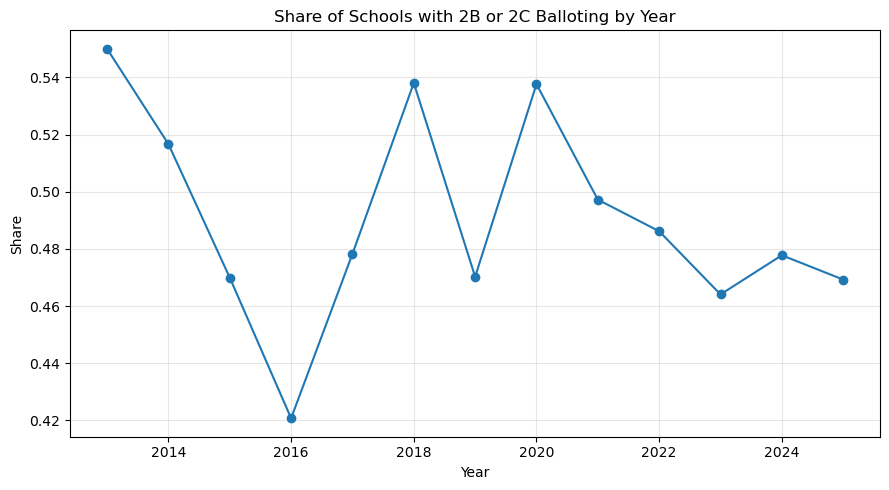

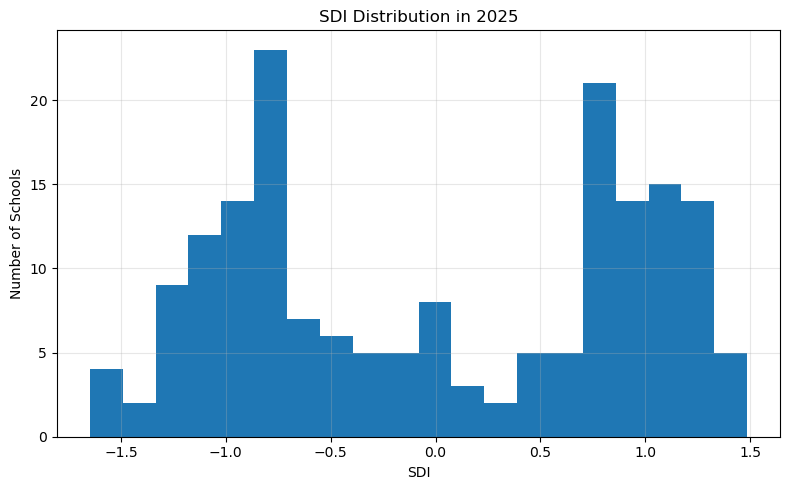

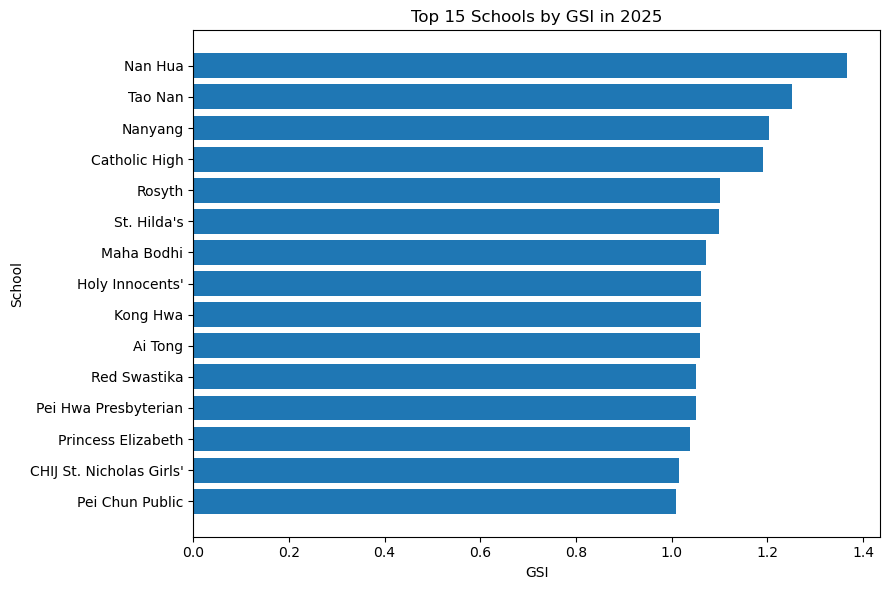

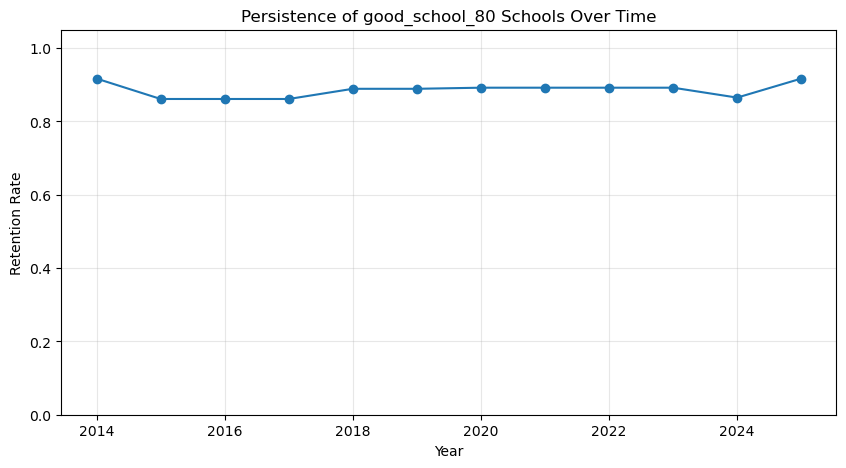

In [75]:

plot_balloted_share_over_time(df_sdi)
plot_sdi_distribution(df_sdi, selected_year=2025)
plot_top_gsi_schools(full_df, selected_year=2025, top_n=15)
plot_good_school_persistence(full_df, flag_col="good_school_80")

## 8. Export final deliverables

In [62]:

final_cols = [
    "school",
    "year",
    "GEP",
    "SAP",
    "GSI",
    "good_school_75",
    "good_school_80",
    "good_school_85",
    "good_school_90",
]

final_output = full_df[final_cols].sort_values(["year", "school"], ascending=[True, True]).reset_index(drop=True)
#final_output.to_csv(FINAL_OUTPUT, index=False)

print(f"Saved final dataset to: {FINAL_OUTPUT}")
final_output.head()

Saved final dataset to: /Users/larryyyyy/Documents/DSA4264/Github project/DSA4264-Public-Policy-and-Society/outputs/Good_School_index/good_school_index_refactored.csv


,school,year,GEP,SAP,GSI,good_school_75,good_school_80,good_school_85,good_school_90
0,Admiralty,2013,0.0,0.0,0.491796,0,0,0,0
1,Ahmad Ibrahim,2013,0.0,0.0,-0.519466,0,0,0,0
2,Ai Tong,2013,0.0,1.0,1.233564,1,1,1,1
3,Alexandra,2013,0.0,0.0,0.430765,0,0,0,0
4,Anchor Green,2013,0.0,0.0,-0.027182,0,0,0,0
